# Supervised Learning Methods

In [2]:
#imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#dataset
from sklearn.datasets import load_breast_cancer

#for reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Task 1: Data Loading & Exploration ()

In [3]:
#display options
pd.set_option('display.max_columns', 40)
pd.set_option('display.width', 160)
sns.set_theme(style='whitegrid', context='notebook')

#load the dataset
data = load_breast_cancer()

#build the df and separate the target
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name='target')

#transform the target into 0-1 instead of malignant-benign
class_names = dict(enumerate(data.target_names))
print('Class label mapping:', class_names)

Class label mapping: {0: 'malignant', 1: 'benign'}


In [4]:
#shape and NA
print(f'Feature matrix X shape: {X.shape}')
print(f'Target vector y shape:  {y.shape}')
print('Data types of features:')
print(X.dtypes.value_counts())
print("\n")
print('Missing values in X?', X.isna().any().any())
print('Missing values in y?', y.isna().any())
print("\n")
X.head()

Feature matrix X shape: (569, 30)
Target vector y shape:  (569,)
Data types of features:
float64    30
Name: count, dtype: int64


Missing values in X? False
Missing values in y? False




,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,radius error,texture error,perimeter error,area error,smoothness error,compactness error,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


AttributeError: Rectangle.set() got an unexpected keyword argument 'legend'

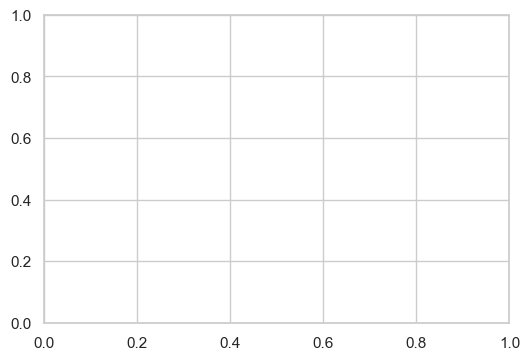

In [5]:
#target balance
counts = y.value_counts().sort_index()
proportions = y.value_counts(normalize=True).sort_index()

balance = pd.DataFrame({
    'count': counts,
    'proportion': proportions.round(3)
})
balance.index = [class_names[i] for i in balance.index]
balance

# Bar plot of target counts
fig, ax = plt.subplots(figsize=(6, 4))
sns.countplot(x=y.map(class_names), order=['malignant', 'benign'],
              hue=y.map(class_names),
              palette={'malignant': '#d62728', 'benign': '#2ca02c'},
              legend=False, ax=ax)
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom', fontsize=11)
ax.set_title('Target balance — Breast Cancer Wisconsin')
ax.set_xlabel('Diagnosis')
ax.set_ylabel('Number of patients')
plt.tight_layout()
plt.show()

In [ ]:
#summary statistics
X.describe().T

#we add a colum with the target for looking what feature separates better the target classes
df_long = X.copy()
df_long['diagnosis'] = y.map(class_names)

feature_groups = ['mean', 'error', 'worst']
fig, axes = plt.subplots(6, 5, figsize=(20, 22))
axes = axes.flatten()

palette = {'malignant': '#d62728', 'benign': '#2ca02c'}

for i, feat in enumerate(X.columns):
    sns.boxplot(data=df_long, x='diagnosis', y=feat,
            order=['malignant', 'benign'],
            hue='diagnosis', palette=palette, legend=False,
            ax=axes[i], width=0.5, fliersize=3)
    axes[i].set_title(feat, fontsize=10)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')

plt.suptitle('Distribution of every feature by diagnosis', fontsize=16, y=1.00)
plt.tight_layout()
plt.show()

#histograms for the 'mean' feature group
mean_features = [c for c in X.columns if c.startswith('mean')]

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()
for i, feat in enumerate(mean_features):
    for cls_id, cls_name in class_names.items():
        axes[i].hist(X.loc[y == cls_id, feat], bins=25, alpha=0.55,
                     label=cls_name, color=palette[cls_name])
    axes[i].set_title(feat, fontsize=10)
    axes[i].legend(fontsize=8)
plt.suptitle("Histograms of the '_mean' features by class", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
#we look (objectibly) what variables distinguish better both classes (malignant-benign)
def standardised_mean_diff(x, group): #cohen's d
    g0 = x[group == 0]
    g1 = x[group == 1]
    pooled_std = np.sqrt((g0.var(ddof=1) + g1.var(ddof=1)) / 2)
    if pooled_std == 0:
        return 0.0
    return (g0.mean() - g1.mean()) / pooled_std

smd = X.apply(lambda col: standardised_mean_diff(col, y)) #apply for every colum
smd_sorted = smd.abs().sort_values(ascending=False)

top10 = smd_sorted.head(10)
fig, ax = plt.subplots(figsize=(8, 5))
top10.iloc[::-1].plot(kind='barh', color='#1f77b4', ax=ax)
ax.set_xlabel("|Standardised mean difference|  (≈ Cohen's d)")
ax.set_title('Top 10 most class-discriminating features')
plt.tight_layout()
plt.show()

print('Top 10 features by separating power:')
print(top10.round(2).to_string())

We can see that all this variables have a smd > 1.5, which means that the variable itself is good separating the clases.

In [ ]:
#correlations

corr = X.corr()

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(corr, cmap='coolwarm', center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.3, cbar_kws={'shrink': 0.7}, ax=ax)
ax.set_title('Pearson correlation heatmap — 30 features', fontsize=14)
plt.tight_layout()
plt.show()

mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
pairs = (
    corr.where(mask)
        .stack()
        .rename('corr')
        .reset_index()
        .rename(columns={'level_0': 'feature_1', 'level_1': 'feature_2'})
)
#rank pair with most correlation
pairs['abs_corr'] = pairs['corr'].abs()
top_pairs = pairs.sort_values('abs_corr', ascending=False).head(15).reset_index(drop=True)
top_pairs.round(3)

# Task 2: Preprocessing & Feature Analysis ()

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# split the data into training (80%) and test (20%) sets. 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE)

# training based normalisation for the models sensitive to feature scale
scaler=StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert back to df 
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X.columns)

print("Training samples: ", X_train.shape[0])
print("Test samples:     ", X_test.shape[0])

# check target is splitted evenly in train and test dataset
print("Target proportion in train dataset:\n", pd.Series(y_train).value_counts(normalize=True))
print("Target proportion in test dataset:\n", pd.Series(y_test).value_counts(normalize=True))

Training samples:  455
Test samples:      114
Target proportion in train dataset:
 target
1    0.626374
0    0.373626
Name: proportion, dtype: float64
Target proportion in test dataset:
 target
1    0.631579
0    0.368421
Name: proportion, dtype: float64


# Task 3: K-Nearest Neighbours ()

# Task 4: Logistic Regression ()

# Task 5: Support Vector Machine ()

# Task 6: Neural Network ()

# Task 7: Model comparison & Evaluation (all)

## 7.1 - KNN model

## 7.2 - Logistic Regression model

## 7.3 - SVM model

## 7.6 - Neural Network

## 7.7 - Final analysis and comparison

### ROC Curves

### Summary table

In [ ]:
#summary table reporting Accuracy, F1-score (macro), AUC, and approximate training time for every model

### Which model you would deploy in a clinical setting and why?